In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


# Task 1: Foundational Setup & Exploratory Data Analysis (EDA)

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** Superstore Sales (or your chosen dataset)

In [16]:
df = pd.read_csv("../data/superstore.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 10800
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [17]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (10800, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID               str
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object


In [18]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


In [19]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 504


In [20]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [21]:
# Make a copy before cleaning
df_clean = df.copy()

# 1. Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# 2. Fill missing Postal Codes with 0
df_clean["Postal Code"] = df_clean["Postal Code"].fillna(0)

# 3. Convert date columns
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"], errors="coerce")
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"], errors="coerce")

# 4. Check the result
print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Remaining duplicates:", df_clean.duplicated().sum())
print("Remaining missing values:", df_clean.isnull().sum().sum())

Original rows: 10800
Rows after cleaning: 10296
Remaining duplicates: 0
Remaining missing values: 5436


In [22]:
df_clean.to_csv("../data/superstore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


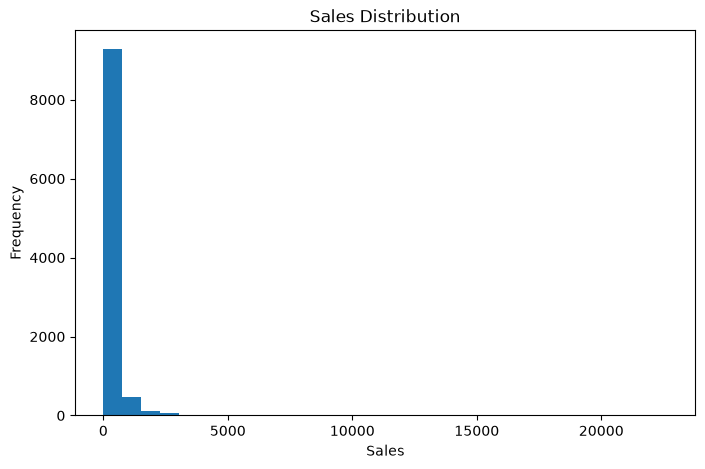

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

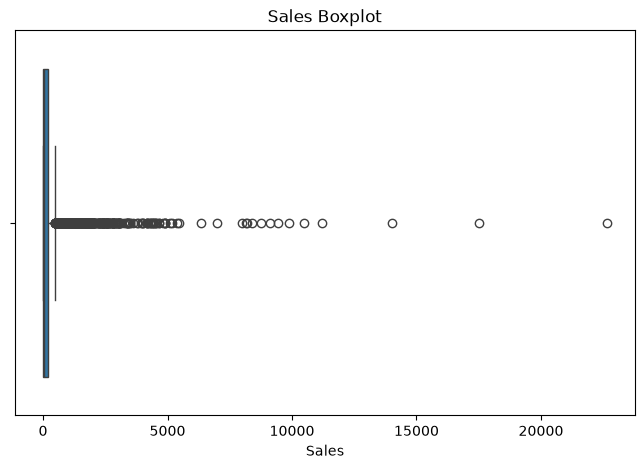

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_clean["Sales"])

plt.title("Sales Boxplot")
plt.xlabel("Sales")

plt.show()

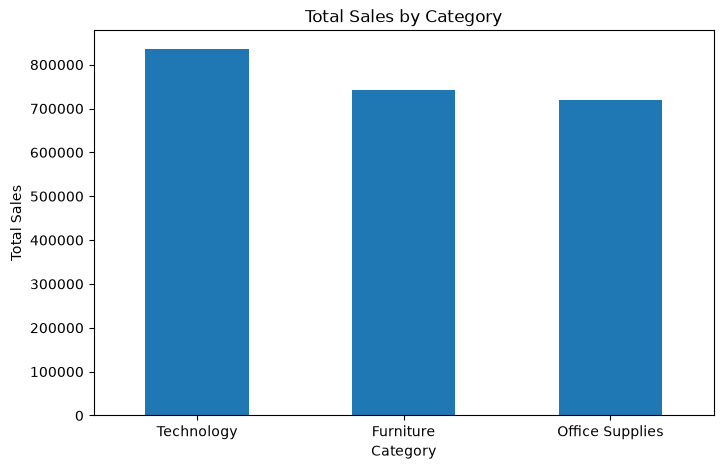

In [25]:
category_sales = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()

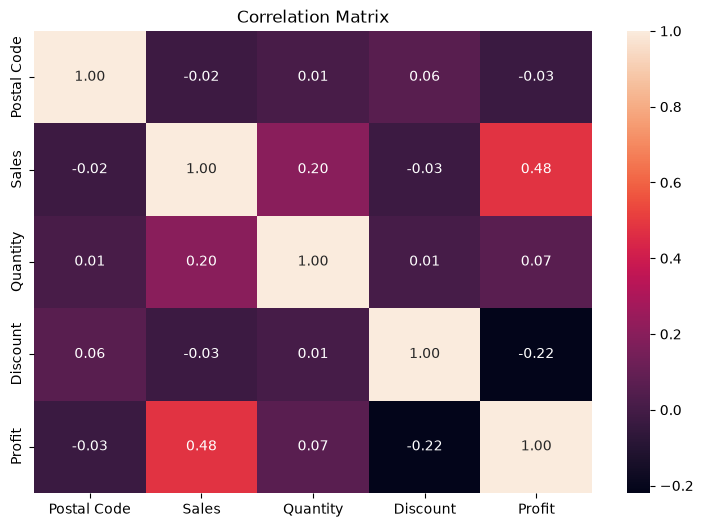

In [26]:
numeric_df = df_clean.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(9, 6))

sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

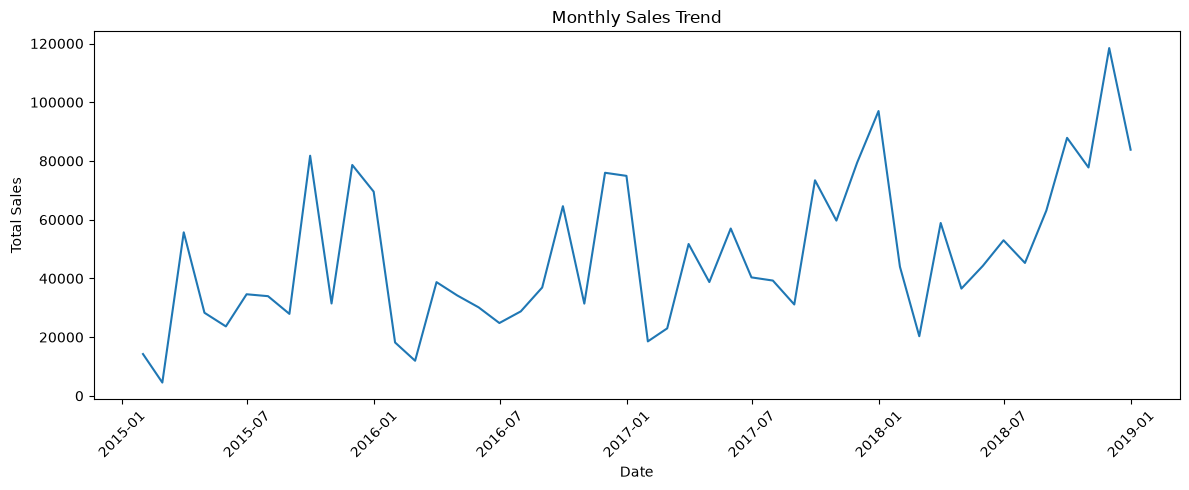

In [27]:
monthly_sales = (
    df_clean
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Key statistics for insights

print("1. Sales by Category:")
print(df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False))

print("\n2. Profit by Category:")
print(df_clean.groupby("Category")["Profit"].sum().sort_values(ascending=False))

print("\n3. Sales by Segment:")
print(df_clean.groupby("Segment")["Sales"].sum().sort_values(ascending=False))

print("\n4. Total Sales:", round(df_clean["Sales"].sum(), 2))
print("5. Total Profit:", round(df_clean["Profit"].sum(), 2))

print("\nHighest Sales Order:", round(df_clean["Sales"].max(), 2))
print("Highest Profit:", round(df_clean["Profit"].max(), 2))

1. Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

2. Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

3. Sales by Segment:
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

4. Total Sales: 2297200.86
5. Total Profit: 286397.02

Highest Sales Order: 22638.48
Highest Profit: 8399.98


## Key Insights

1. **Technology** is the category with the highest total sales, making it the strongest contributor to overall revenue.

2. **Technology** also generates the highest overall profit among the major product categories.

3. The **Consumer** segment contributes the highest total sales compared with the other customer segments.

4. The Sales distribution and boxplot show that most transactions have relatively moderate sales values, while a small number of orders have very high sales values.

5. Sales and profit do not always increase at the same rate, showing that high sales volume does not necessarily guarantee the highest profitability.

## Conclusion

The Superstore Sales dataset was successfully cleaned and analyzed using Python. Duplicate records and missing values were handled, data types were corrected, and the cleaned dataset was saved. Exploratory analysis using histograms, boxplots, bar charts, a correlation heatmap, and a monthly sales trend helped identify important patterns in sales, profit, categories, and customer segments.